In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================

import yfinance as yf # Getting too many request errors.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅ All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"yfinance version: {yf.__version__}")

✅ All libraries imported successfully!
pandas version: 3.0.1
yfinance version: 0.2.57


In [2]:
# ============================================================
# CELL 2 — Simulated stock data (GBM — used in real quant finance)
# ============================================================

np.random.seed(42)
dates = pd.bdate_range(start='2022-01-03', end='2024-12-31') 
n = len(dates)

def simulate_stock(start_price, annual_volatility, annual_drift):
    daily_vol   = annual_volatility / np.sqrt(252)
    daily_drift = annual_drift / 252
    shocks  = np.random.normal(daily_drift, daily_vol, n)
    prices  = start_price * np.exp(np.cumsum(shocks))
    return np.round(prices, 2)

prices = pd.DataFrame({
    'AAPL': simulate_stock(182,  0.28, 0.12),
    'TSLA': simulate_stock(400,  0.65, 0.05),
    'MSFT': simulate_stock(336,  0.25, 0.15),
}, index=dates)

prices.index.name = 'Date'

os.makedirs('../data', exist_ok=True)
prices.to_csv('../data/close_prices.csv')

print(f"✅ Data ready!")
print(f"📐 Shape: {prices.shape}")
print(f"🗓️  {prices.index[0].date()} → {prices.index[-1].date()}")
prices.head()

✅ Data ready!
📐 Shape: (782, 3)
🗓️  2022-01-03 → 2024-12-31


,AAPL,TSLA,MSFT
Date,,,
2022-01-03,183.69,406.36,340.12
2022-01-04,183.33,416.73,338.82
2022-01-05,185.52,426.47,339.38
2022-01-06,190.67,445.86,342.35
2022-01-07,189.97,461.44,334.23


In [3]:
# ============================================================
# CELL 3 — Load data from disk
# ============================================================

prices = pd.read_csv(
    '../data/close_prices.csv',
    index_col  = 'Date',       # make Date the row label, not a regular column
    parse_dates = True          # convert the Date column to datetime format
)

print("✅ Data loaded from CSV")
print(f"📐 Shape: {prices.shape}")
print(f"📋 Columns: {prices.columns.tolist()}")
print(f"🗓️  Index type: {type(prices.index)}")
prices.head()

✅ Data loaded from CSV
📐 Shape: (782, 3)
📋 Columns: ['AAPL', 'TSLA', 'MSFT']
🗓️  Index type: <class 'pandas.DatetimeIndex'>


,AAPL,TSLA,MSFT
Date,,,
2022-01-03,183.69,406.36,340.12
2022-01-04,183.33,416.73,338.82
2022-01-05,185.52,426.47,339.38
2022-01-06,190.67,445.86,342.35
2022-01-07,189.97,461.44,334.23


In [4]:
# ============================================================
# CELL 4 — Understand structure
# ============================================================

print("=" * 45)
print("📐 SHAPE")
print("=" * 45)
rows, cols = prices.shape
print(f"  Rows    : {rows}  (one per trading day)")
print(f"  Columns : {cols}  (one per stock)")

print("\n" + "=" * 45)
print("📋 COLUMN DATATYPES")
print("=" * 45)
print(prices.dtypes)

print("\n" + "=" * 45)
print("🗓️  DATE RANGE")
print("=" * 45)
print(f"  Start : {prices.index.min().date()}")
print(f"  End   : {prices.index.max().date()}")
print(f"  Years : {(prices.index.max() - prices.index.min()).days / 365:.1f}")

📐 SHAPE
  Rows    : 782  (one per trading day)
  Columns : 3  (one per stock)

📋 COLUMN DATATYPES
AAPL    float64
TSLA    float64
MSFT    float64
dtype: object

🗓️  DATE RANGE
  Start : 2022-01-03
  End   : 2024-12-31
  Years : 3.0


In [5]:
# ============================================================
# CELL 5 — .info() — the data scientist's first move
# ============================================================

print("📋 DataFrame Info:")
print("-" * 45)
prices.info()

📋 DataFrame Info:
---------------------------------------------
<class 'pandas.DataFrame'>
DatetimeIndex: 782 entries, 2022-01-03 to 2024-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    782 non-null    float64
 1   TSLA    782 non-null    float64
 2   MSFT    782 non-null    float64
dtypes: float64(3)
memory usage: 24.4 KB


In [6]:
# ============================================================
# CELL 6 — Statistical summary
# ============================================================

print("📊 Summary Statistics:")
print("-" * 45)
pd.set_option('display.float_format', '{:.2f}'.format)  # show 2 decimal places
prices.describe()

📊 Summary Statistics:
---------------------------------------------


,AAPL,TSLA,MSFT
count,782.00,782.00,782.00
mean,210.19,4335.19,495.76
std,32.41,3651.56,84.83
min,150.72,406.36,294.50
25%,185.81,1494.25,459.31
50%,213.22,3845.32,511.99
75%,233.93,5091.69,544.00
max,294.15,17031.96,722.02


In [7]:
# ============================================================
# CELL 7 — First and last rows
# ============================================================

print("🔼 FIRST 5 TRADING DAYS (Jan 2022):")
print(prices.head())

print("\n🔽 LAST 5 TRADING DAYS (Dec 2024):")
print(prices.tail())

print("\n📈 Price change over 3 years:")
for col in prices.columns:
    start = prices[col].iloc[0]
    end   = prices[col].iloc[-1]
    change = ((end - start) / start) * 100
    emoji = "📈" if change > 0 else "📉"
    print(f"  {emoji} {col}: ${start:.2f} → ${end:.2f}  ({change:+.1f}%)")

🔼 FIRST 5 TRADING DAYS (Jan 2022):
             AAPL   TSLA   MSFT
Date                           
2022-01-03 183.69 406.36 340.12
2022-01-04 183.33 416.73 338.82
2022-01-05 185.52 426.47 339.38
2022-01-06 190.67 445.86 342.35
2022-01-07 189.97 461.44 334.23

🔽 LAST 5 TRADING DAYS (Dec 2024):
             AAPL     TSLA   MSFT
Date                             
2024-12-25 228.10 13624.63 716.02
2024-12-26 227.91 13615.42 722.02
2024-12-27 230.52 13207.78 716.49
2024-12-30 231.36 11962.07 693.01
2024-12-31 226.08 12405.47 705.51

📈 Price change over 3 years:
  📈 AAPL: $183.69 → $226.08  (+23.1%)
  📈 TSLA: $406.36 → $12405.47  (+2952.8%)
  📈 MSFT: $340.12 → $705.51  (+107.4%)


In [8]:
# ============================================================
# CELL 8 — Check for missing values
# ============================================================

print("🔍 Missing Value Check:")
print("-" * 45)

# Count NaNs per column
null_counts = prices.isnull().sum()
print(null_counts)

print(f"\n📊 Total missing values: {prices.isnull().sum().sum()}")
print(f"📊 Total cells: {prices.shape[0] * prices.shape[1]}")

# Visual percentage
print("\n📋 Missing percentage per column:")
for col in prices.columns:
    pct = (prices[col].isnull().sum() / len(prices)) * 100
    bar = "█" * int(pct) if pct > 0 else "✅ None"
    print(f"  {col}: {pct:.2f}%  {bar}")

🔍 Missing Value Check:
---------------------------------------------
AAPL    0
TSLA    0
MSFT    0
dtype: int64

📊 Total missing values: 0
📊 Total cells: 2346

📋 Missing percentage per column:
  AAPL: 0.00%  ✅ None
  TSLA: 0.00%  ✅ None
  MSFT: 0.00%  ✅ None


In [9]:
# ============================================================
# CELL 9 — Check for duplicate dates
# ============================================================

print("🔍 Duplicate Row Check:")
print("-" * 45)

duplicates = prices.index.duplicated().sum()
print(f"  Duplicate dates found: {duplicates}")

if duplicates > 0:
    print("\n⚠️  Duplicates found! Removing...")
    prices = prices[~prices.index.duplicated(keep='first')]
    print(f"  ✅ Removed. New shape: {prices.shape}")
else:
    print("  ✅ No duplicates — index is clean")

🔍 Duplicate Row Check:
---------------------------------------------
  Duplicate dates found: 0
  ✅ No duplicates — index is clean


In [10]:
# ============================================================
# CELL 10 — Validate and enforce correct data types
# ============================================================

print("🔍 Data Type Validation:")
print("-" * 45)
print(prices.dtypes)

# Enforce float64 for all price columns — defensive programming
for col in prices.columns:
    prices[col] = prices[col].astype('float64')

print("\n✅ All price columns confirmed as float64")

# Verify index is DatetimeIndex
print(f"\n🗓️  Index type: {type(prices.index).__name__}")
assert isinstance(prices.index, pd.DatetimeIndex), "❌ Index must be DatetimeIndex!"
print("✅ Index confirmed as DatetimeIndex")

🔍 Data Type Validation:
---------------------------------------------
AAPL    float64
TSLA    float64
MSFT    float64
dtype: object

✅ All price columns confirmed as float64

🗓️  Index type: DatetimeIndex
✅ Index confirmed as DatetimeIndex


In [11]:
# ============================================================
# CELL 11 — Sanity check: prices must be positive
# ============================================================

print("🔍 Price Sanity Check:")
print("-" * 45)

for col in prices.columns:
    zeros    = (prices[col] == 0).sum()
    negatives = (prices[col] < 0).sum()
    minimum  = prices[col].min()
    
    status = "✅" if zeros == 0 and negatives == 0 else "❌"
    print(f"  {status} {col}:  min=${minimum:.2f}  |  zeros={zeros}  |  negatives={negatives}")

print("\n✅ All prices are positive — data is valid")

🔍 Price Sanity Check:
---------------------------------------------
  ✅ AAPL:  min=$150.72  |  zeros=0  |  negatives=0
  ✅ TSLA:  min=$406.36  |  zeros=0  |  negatives=0
  ✅ MSFT:  min=$294.50  |  zeros=0  |  negatives=0

✅ All prices are positive — data is valid


In [12]:
# ============================================================
# CELL 12 — Outlier detection
# A Z-score tells you how many standard deviations
# a value is from the mean. Above 3 = potential outlier
# ============================================================

print("🔍 Outlier Detection (Z-score method):")
print("-" * 45)

from scipy import stats

for col in prices.columns:
    z_scores = np.abs(stats.zscore(prices[col]))
    outliers = (z_scores > 3).sum()
    print(f"  {col}: {outliers} potential outliers (|z| > 3)")

print("""
💡 Note: In stock data, extreme values aren't always
   errors — they can be real market crashes or rallies.
   We flag them but don't automatically remove them.
""")

🔍 Outlier Detection (Z-score method):
---------------------------------------------
  AAPL: 0 potential outliers (|z| > 3)
  TSLA: 5 potential outliers (|z| > 3)
  MSFT: 0 potential outliers (|z| > 3)

💡 Note: In stock data, extreme values aren't always
   errors — they can be real market crashes or rallies.
   We flag them but don't automatically remove them.



In [13]:
# ============================================================
# CELL 13 — Check for unexpected gaps in trading days
# ============================================================

print("🔍 Trading Day Gap Check:")
print("-" * 45)

# Calculate gaps between consecutive trading days
gaps = prices.index.to_series().diff().dt.days

# Gaps > 5 days are suspicious (normal is 1 weekday, 3 over weekends)
large_gaps = gaps[gaps > 5]

print(f"  Total date gaps checked : {len(gaps)}")
print(f"  Gaps larger than 5 days : {len(large_gaps)}")

if len(large_gaps) > 0:
    print("\n⚠️  Large gaps found:")
    for date, gap in large_gaps.items():
        print(f"    {date.date()} — {gap} day gap")
else:
    print("  ✅ No suspicious gaps found")

print(f"\n  Normal gap stats:")
print(f"    Most common gap : {gaps.mode()[0]:.0f} day(s)")
print(f"    Max gap         : {gaps.max():.0f} day(s)")

🔍 Trading Day Gap Check:
---------------------------------------------
  Total date gaps checked : 782
  Gaps larger than 5 days : 0
  ✅ No suspicious gaps found

  Normal gap stats:
    Most common gap : 1 day(s)
    Max gap         : 3 day(s)


In [14]:
# ============================================================
# CELL 15 — Daily Returns
# ============================================================

# pct_change() computes: (today - yesterday) / yesterday
# This gives us the daily % gain or loss as a decimal
# e.g. 0.02 means +2%, -0.015 means -1.5%

daily_returns = prices.pct_change() # Calculate the percentage from previous raw.

# First row will always be NaN — no "yesterday" to compare to
# Drop it cleanly
daily_returns = daily_returns.dropna() # Remove rows that contain missing values (NaN).

print("✅ Daily Returns computed!")
print(f"📐 Shape: {daily_returns.shape}")
print(f"\n📋 First 5 rows:")
print(daily_returns.head())

print(f"\n📋 Sample interpretation:")
for col in daily_returns.columns:
    val = daily_returns[col].iloc[0]
    direction = "gained" if val > 0 else "-lost"
    print(f"  {col}: {direction} {abs(val)*100:.2f}% on day 1")

✅ Daily Returns computed!
📐 Shape: (781, 3)

📋 First 5 rows:
            AAPL  TSLA  MSFT
Date                        
2022-01-04 -0.00  0.03 -0.00
2022-01-05  0.01  0.02  0.00
2022-01-06  0.03  0.05  0.01
2022-01-07 -0.00  0.03 -0.02
2022-01-10 -0.00  0.02 -0.01

📋 Sample interpretation:
  AAPL: -lost 0.20% on day 1
  TSLA: gained 2.55% on day 1
  MSFT: -lost 0.38% on day 1


In [15]:
# ============================================================
# CELL 16 — Cumulative Returns
# ============================================================

# (1 + daily_return) compounds each day
# cumprod() multiplies them all together progressively
# Subtract 1 to get the total % gain from start

cumulative_returns = (1 + daily_returns).cumprod() - 1

print("✅ Cumulative Returns computed!")
print(f"\n📋 First 5 rows:")
print(cumulative_returns.head())

print(f"\n🏆 Total return over 3 years:")
for col in cumulative_returns.columns:
    total = cumulative_returns[col].iloc[-1] * 100
    emoji = "📈" if total > 0 else "📉"
    print(f"  {emoji} {col}: {total:+.1f}%")

✅ Cumulative Returns computed!

📋 First 5 rows:
            AAPL  TSLA  MSFT
Date                        
2022-01-04 -0.00  0.03 -0.00
2022-01-05  0.01  0.05 -0.00
2022-01-06  0.04  0.10  0.01
2022-01-07  0.03  0.14 -0.02
2022-01-10  0.03  0.16 -0.02

🏆 Total return over 3 years:
  📈 AAPL: +23.1%
  📈 TSLA: +2952.8%
  📈 MSFT: +107.4%


In [16]:
# ============================================================
# CELL 17 — Moving Averages (50-day and 200-day)
# ============================================================

# We'll compute for each stock separately
# Store them in a dictionary for easy access

ma_data = {}

for col in prices.columns:
    ma_data[col] = pd.DataFrame({
        'Price'  : prices[col],
        'MA50'   : prices[col].rolling(window=50).mean(),
        'MA200'  : prices[col].rolling(window=200).mean(),
    })

# Preview AAPL
print("✅ Moving averages computed for all stocks!")
print(f"\n📋 AAPL (first rows with MA values — NaN until enough data):")
print(ma_data['AAPL'].head(10))

print(f"\n📋 AAPL (rows 200+ — both MAs now populated):")
print(ma_data['AAPL'].iloc[200:205])

✅ Moving averages computed for all stocks!

📋 AAPL (first rows with MA values — NaN until enough data):
            Price  MA50  MA200
Date                          
2022-01-03 183.69   NaN    NaN
2022-01-04 183.33   NaN    NaN
2022-01-05 185.52   NaN    NaN
2022-01-06 190.67   NaN    NaN
2022-01-07 189.97   NaN    NaN
2022-01-10 189.28   NaN    NaN
2022-01-11 194.72   NaN    NaN
2022-01-12 197.46   NaN    NaN
2022-01-13 195.93   NaN    NaN
2022-01-14 197.91   NaN    NaN

📋 AAPL (rows 200+ — both MAs now populated):
            Price   MA50  MA200
Date                           
2022-10-10 174.55 172.43 166.34
2022-10-11 176.37 172.78 166.31
2022-10-12 179.86 173.23 166.28
2022-10-13 183.32 173.74 166.24
2022-10-14 179.00 174.14 166.19


In [17]:
# ============================================================
# CELL 18 — Rolling Volatility (30-day window)
# ============================================================

# Standard deviation of daily returns over a rolling 30-day window
# Annualize it by multiplying by sqrt(252) — 252 trading days/year
# This gives us volatility in the same units as annual returns

rolling_vol = daily_returns.rolling(window=30).std() * np.sqrt(252)

print("✅ Rolling volatility computed!")
print(f"\n📋 First populated rows (day 30+):")
print(rolling_vol.iloc[30:33])

print(f"\n📊 Average annualized volatility over 3 years:")
for col in rolling_vol.columns:
    avg_vol = rolling_vol[col].mean() * 100
    print(f"  {col}: {avg_vol:.1f}% per year")

✅ Rolling volatility computed!

📋 First populated rows (day 30+):
            AAPL  TSLA  MSFT
Date                        
2022-02-15  0.27  0.49  0.25
2022-02-16  0.27  0.50  0.26
2022-02-17  0.26  0.51  0.28

📊 Average annualized volatility over 3 years:
  AAPL: 27.6% per year
  TSLA: 64.7% per year
  MSFT: 24.4% per year


In [19]:
# ============================================================
# CELL 19 — Risk vs Return summary per stock
# ============================================================

print("=" * 52)
print(f"{'Stock':<8} {'Avg Daily Return':>17} {'Annual Vol':>12} {'Return/Risk':>12}")
print("=" * 52)

for col in daily_returns.columns:
    avg_daily   = daily_returns[col].mean()
    annual_ret  = avg_daily * 252 * 100          # annualize
    annual_vol  = daily_returns[col].std() * np.sqrt(252) * 100
    ratio       = annual_ret / annual_vol        # return per unit of risk

    print(f"{col:<8} {annual_ret:>16.2f}%  {annual_vol:>11.2f}%  {ratio:>11.3f}x")

print("=" * 52)
print("""
💡 Return/Risk interpretation:
   Higher = better (more return for each unit of risk)
   MSFT likely leads — steady growth, lower volatility
   TSLA likely trails — high volatility eats the return
""")

Stock     Avg Daily Return   Annual Vol  Return/Risk
AAPL                10.53%        27.73%        0.380x
TSLA               131.48%        64.92%        2.025x
MSFT                26.53%        24.43%        1.086x

💡 Return/Risk interpretation:
   Higher = better (more return for each unit of risk)
   MSFT likely leads — steady growth, lower volatility
   TSLA likely trails — high volatility eats the return



In [20]:
# ============================================================
# CELL 20 — Save all engineered features to disk
# ============================================================

daily_returns.to_csv('../data/daily_returns.csv')
cumulative_returns.to_csv('../data/cumulative_returns.csv')
rolling_vol.to_csv('../data/rolling_volatility.csv')

# Save moving averages for each stock
for col in prices.columns:
    ma_data[col].to_csv(f'../data/ma_{col.lower()}.csv')

print("💾 All engineered features saved:")
print("   → data/daily_returns.csv")
print("   → data/cumulative_returns.csv")
print("   → data/rolling_volatility.csv")
print("   → data/ma_aapl.csv")
print("   → data/ma_tsla.csv")
print("   → data/ma_msft.csv")

import os
print(f"\n📁 data/ folder now contains {len(os.listdir('../data'))} files:")
for f in sorted(os.listdir('../data')):
    size = os.path.getsize(f'../data/{f}') / 1024
    print(f"   {f} ({size:.1f} KB)")

💾 All engineered features saved:
   → data/daily_returns.csv
   → data/cumulative_returns.csv
   → data/rolling_volatility.csv
   → data/ma_aapl.csv
   → data/ma_tsla.csv
   → data/ma_msft.csv

📁 data/ folder now contains 7 files:
   close_prices.csv (24.9 KB)
   cumulative_returns.csv (52.4 KB)
   daily_returns.csv (57.1 KB)
   ma_aapl.csv (30.9 KB)
   ma_msft.csv (29.7 KB)
   ma_tsla.csv (31.2 KB)
   rolling_volatility.csv (51.0 KB)


In [21]:
# ============================================================
# CELL 21 — Professional plot styling
# ============================================================

plt.style.use('seaborn-v0_8-darkgrid')  # clean professional background

# Global settings — applied to every chart automatically
plt.rcParams.update({
    'figure.figsize'    : (14, 6),
    'font.size'         : 12,
    'axes.titlesize'    : 15,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 12,
    'legend.fontsize'   : 11,
    'lines.linewidth'   : 1.8,
    'figure.dpi'        : 120,
})

# Color palette — one distinct color per stock, used consistently
COLORS = {
    'AAPL': '#2196F3',   # blue
    'TSLA': '#F44336',   # red
    'MSFT': '#4CAF50',   # green
}

os.makedirs('../outputs', exist_ok=True)

print("✅ Plot styling configured!")
print(f"   Colors: {COLORS}")

✅ Plot styling configured!
   Colors: {'AAPL': '#2196F3', 'TSLA': '#F44336', 'MSFT': '#4CAF50'}


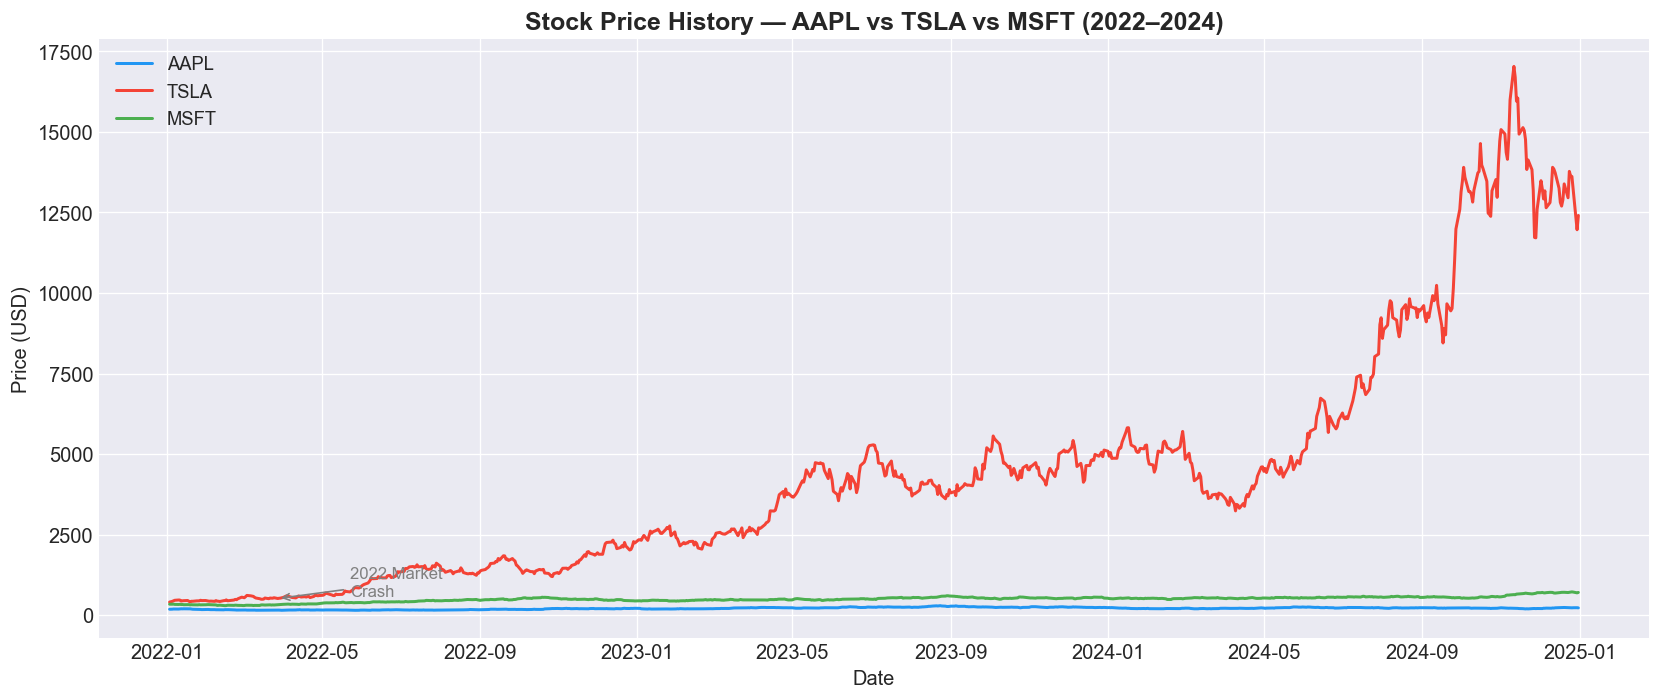

💾 Saved → outputs/01_price_history.png


In [23]:
# ============================================================
# CELL 22 — Chart 1: Stock Price History
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

for col in prices.columns:
    ax.plot(
        prices.index,
        prices[col],
        label     = col,
        color     = COLORS[col],
        linewidth = 1.8
    )

# Labels and formatting
ax.set_title('Stock Price History — AAPL vs TSLA vs MSFT (2022–2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left')

# Add a text annotation — professional touch
ax.annotate(
    '2022 Market\nCrash',
    xy         = (prices.index[60], prices['TSLA'].iloc[60]),
    xytext     = (prices.index[100], prices['TSLA'].iloc[60] + 80),
    arrowprops = dict(arrowstyle='->', color='gray'),
    fontsize   = 10,
    color      = 'gray'
)

plt.tight_layout()
plt.savefig('../outputs/01_price_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved → outputs/01_price_history.png")

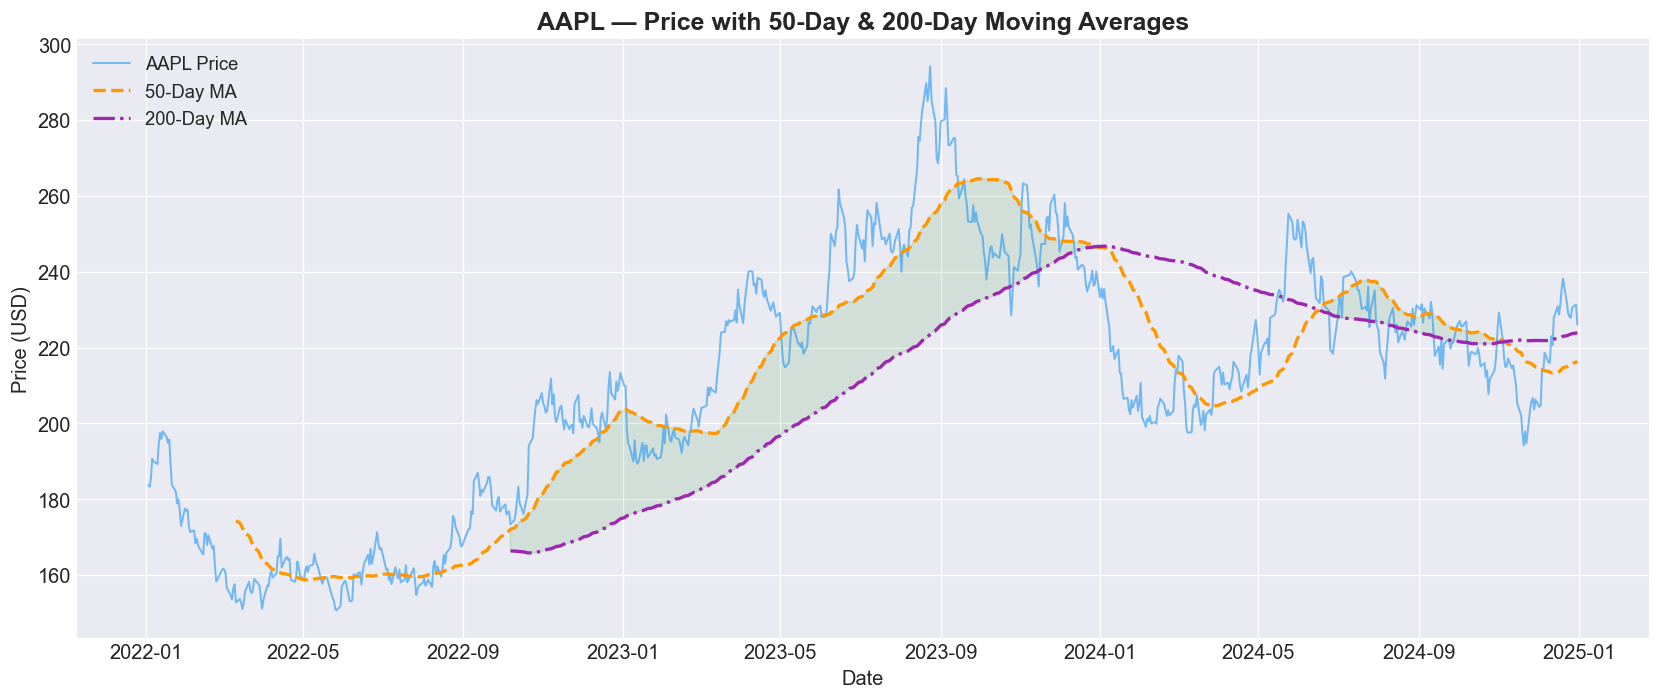

💾 Saved → outputs/02_moving_averages.png


In [24]:
# ============================================================
# CELL 23 — Chart 2: Moving Averages (AAPL deep dive)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Price line
ax.plot(
    ma_data['AAPL'].index,
    ma_data['AAPL']['Price'],
    label     = 'AAPL Price',
    color     = COLORS['AAPL'],
    alpha     = 0.6,          # slightly transparent so MAs stand out
    linewidth = 1.2
)

# 50-day MA
ax.plot(
    ma_data['AAPL'].index,
    ma_data['AAPL']['MA50'],
    label     = '50-Day MA',
    color     = '#FF9800',    # orange
    linewidth = 2.0,
    linestyle = '--'
)

# 200-day MA
ax.plot(
    ma_data['AAPL'].index,
    ma_data['AAPL']['MA200'],
    label     = '200-Day MA',
    color     = '#9C27B0',    # purple
    linewidth = 2.0,
    linestyle = '-.'
)

ax.set_title('AAPL — Price with 50-Day & 200-Day Moving Averages')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left')

# Shade the area where MA50 > MA200 (bullish zone)
ax.fill_between(
    ma_data['AAPL'].index,
    ma_data['AAPL']['MA50'],
    ma_data['AAPL']['MA200'],
    where  = ma_data['AAPL']['MA50'] > ma_data['AAPL']['MA200'],
    alpha  = 0.1,
    color  = 'green',
    label  = 'Bullish zone'
)

plt.tight_layout()
plt.savefig('../outputs/02_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved → outputs/02_moving_averages.png")

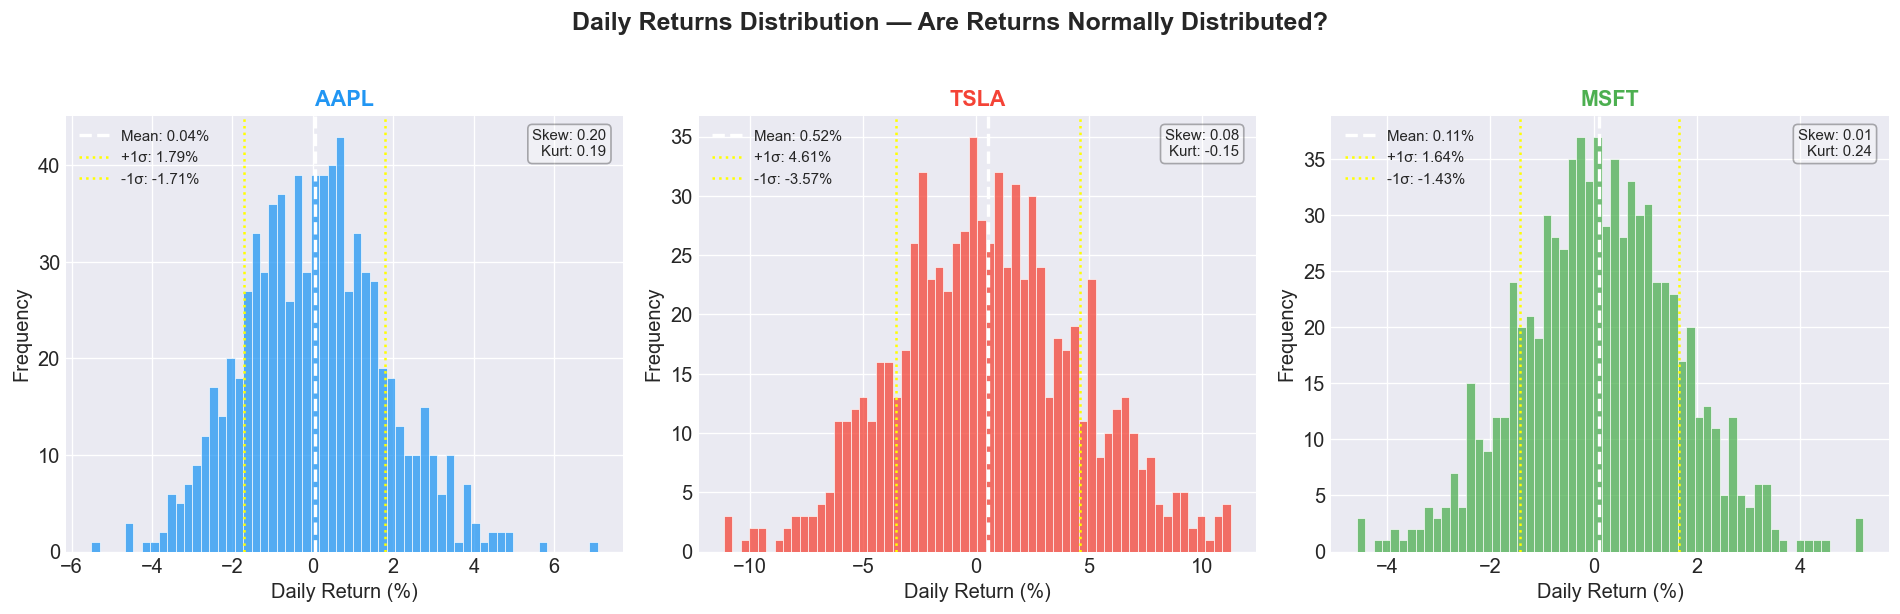

💾 Saved → outputs/03_returns_distribution.png


In [25]:
# ============================================================
# CELL 24 — Chart 3: Daily Returns Distribution
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Daily Returns Distribution — Are Returns Normally Distributed?',
             fontsize=15, fontweight='bold', y=1.02)

for i, col in enumerate(daily_returns.columns):
    ax = axes[i]
    
    returns_pct = daily_returns[col] * 100  # convert to percentage
    
    # Histogram
    ax.hist(
        returns_pct,
        bins      = 60,
        color     = COLORS[col],
        alpha     = 0.75,
        edgecolor = 'white',
        linewidth = 0.5
    )
    
    # Add vertical lines for mean and ±1 std
    mean = returns_pct.mean()
    std  = returns_pct.std()
    
    ax.axvline(mean, color='white',  linewidth=2,   linestyle='--', label=f'Mean: {mean:.2f}%')
    ax.axvline(mean + std, color='yellow', linewidth=1.5, linestyle=':', label=f'+1σ: {mean+std:.2f}%')
    ax.axvline(mean - std, color='yellow', linewidth=1.5, linestyle=':', label=f'-1σ: {mean-std:.2f}%')
    
    ax.set_title(col, fontsize=13, fontweight='bold', color=COLORS[col])
    ax.set_xlabel('Daily Return (%)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    
    # Add skewness annotation
    skew = returns_pct.skew()
    kurt = returns_pct.kurt()
    ax.text(
        0.97, 0.97,
        f'Skew: {skew:.2f}\nKurt: {kurt:.2f}',
        transform            = ax.transAxes,
        ha                   = 'right',
        va                   = 'top',
        fontsize             = 9,
        bbox                 = dict(boxstyle='round', facecolor='white', alpha=0.3)
    )

plt.tight_layout()
plt.savefig('../outputs/03_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved → outputs/03_returns_distribution.png")

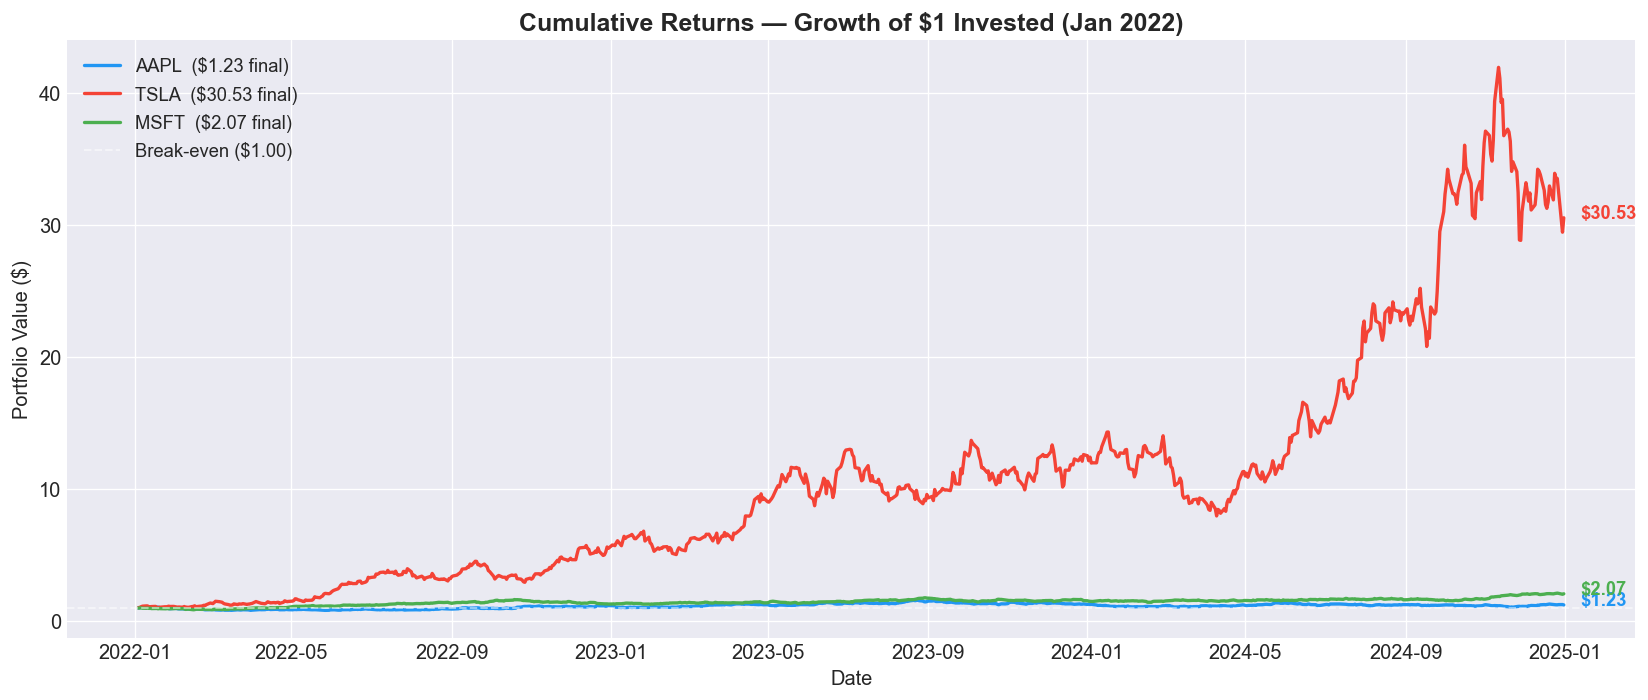

💾 Saved → outputs/04_cumulative_returns.png


In [26]:
# ============================================================
# CELL 25 — Chart 4: Cumulative Returns ($1 invested)
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Convert to "growth of $1" — easier to read than percentages
growth = (1 + daily_returns).cumprod()

for col in growth.columns:
    final = growth[col].iloc[-1]
    ax.plot(
        growth.index,
        growth[col],
        label     = f'{col}  (${final:.2f} final)',
        color     = COLORS[col],
        linewidth = 2.0
    )

# Reference line — flat $1 (no gain, no loss)
ax.axhline(
    y         = 1.0,
    color     = 'white',
    linewidth = 1.2,
    linestyle = '--',
    alpha     = 0.5,
    label     = 'Break-even ($1.00)'
)

ax.set_title('Cumulative Returns — Growth of $1 Invested (Jan 2022)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($)')
ax.legend(loc='upper left')

# Add dollar labels at the end of each line
for col in growth.columns:
    final_val  = growth[col].iloc[-1]
    final_date = growth.index[-1]
    ax.annotate(
        f'${final_val:.2f}',
        xy       = (final_date, final_val),
        xytext   = (10, 0),
        textcoords = 'offset points',
        color    = COLORS[col],
        fontweight = 'bold',
        fontsize = 11
    )

plt.tight_layout()
plt.savefig('../outputs/04_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved → outputs/04_cumulative_returns.png")

📊 Correlation Matrix:
      AAPL  TSLA  MSFT
AAPL  1.00  0.03 -0.06
TSLA  0.03  1.00 -0.05
MSFT -0.06 -0.05  1.00


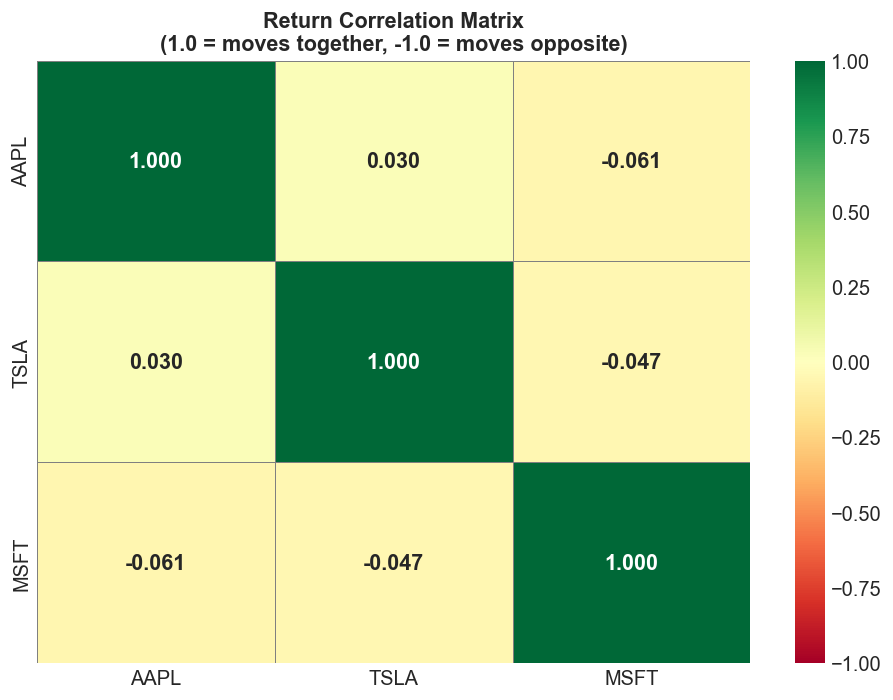


💾 Saved → outputs/05_correlation_heatmap.png


In [27]:
# ============================================================
# CELL 26 — Chart 5: Correlation Heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Compute correlation matrix of daily returns
# We use returns, not prices — price correlations are misleading
corr_matrix = daily_returns.corr()

print("📊 Correlation Matrix:")
print(corr_matrix.round(3))

# Draw heatmap
sns.heatmap(
    corr_matrix,
    annot      = True,          # show numbers in each cell
    fmt        = '.3f',         # 3 decimal places
    cmap       = 'RdYlGn',      # red = negative, yellow = neutral, green = positive
    vmin       = -1,
    vmax       = 1,
    linewidths = 0.5,
    linecolor  = 'gray',
    ax         = ax,
    annot_kws  = {'size': 13, 'weight': 'bold'}
)

ax.set_title('Return Correlation Matrix\n(1.0 = moves together, -1.0 = moves opposite)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved → outputs/05_correlation_heatmap.png")

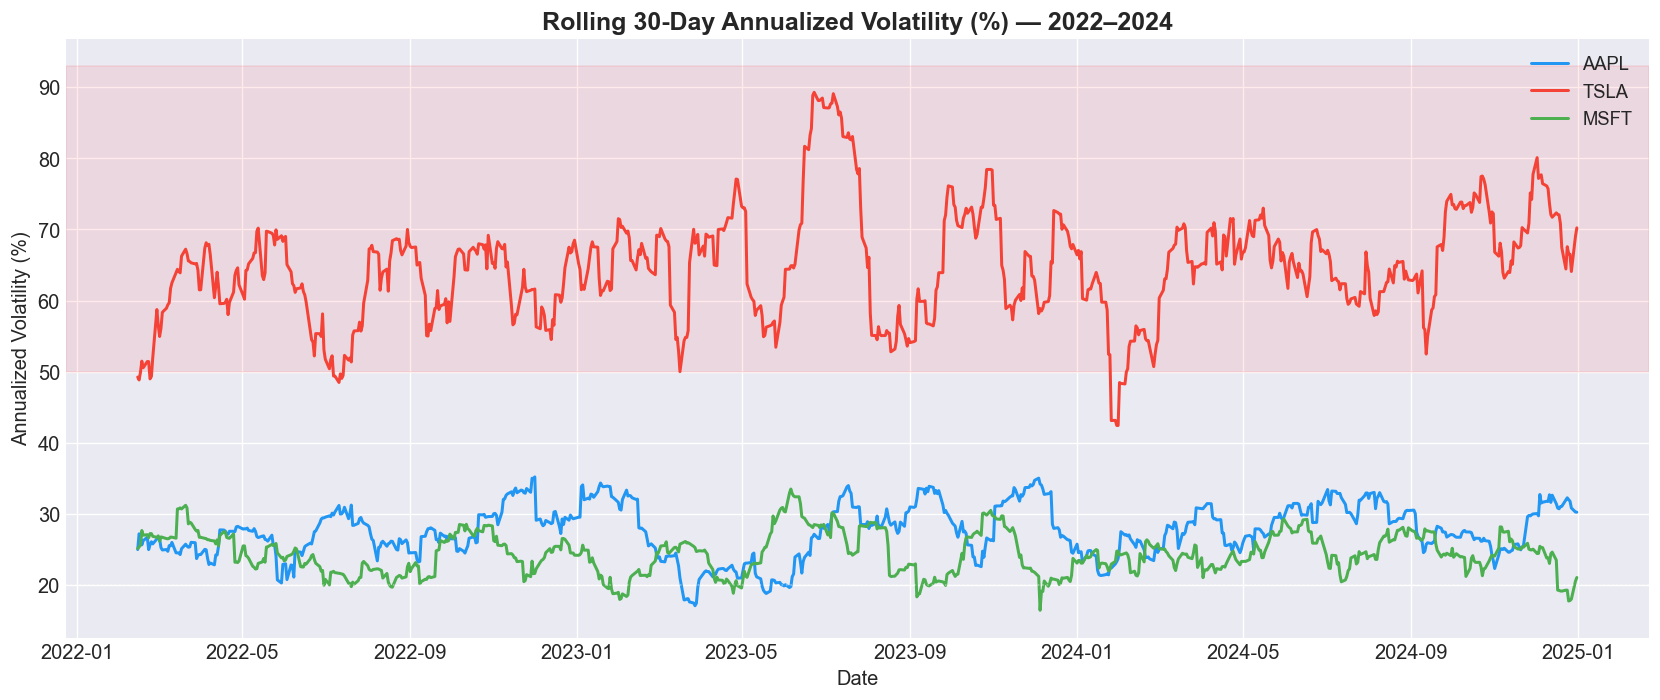

💾 Saved → outputs/06_rolling_volatility.png


In [28]:
# ============================================================
# CELL 27 — Chart 6: Rolling 30-Day Volatility
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

for col in rolling_vol.columns:
    ax.plot(
        rolling_vol.index,
        rolling_vol[col] * 100,   # convert to percentage
        label     = col,
        color     = COLORS[col],
        linewidth = 1.8
    )

ax.set_title('Rolling 30-Day Annualized Volatility (%) — 2022–2024')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Volatility (%)')
ax.legend(loc='upper right')

# Shade high-volatility zone
ax.axhspan(
    ymin  = 50,
    ymax  = ax.get_ylim()[1] if ax.get_ylim()[1] > 50 else 100,
    alpha = 0.08,
    color = 'red',
    label = 'High volatility zone'
)

# Reference lines
ax.axhline(y=20, color='white', linewidth=1, linestyle=':', alpha=0.4, label='S&P 500 avg (~20%)')

plt.tight_layout()
plt.savefig('../outputs/06_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved → outputs/06_rolling_volatility.png")

In [31]:
# ============================================================
# CELL 28 — EDA Summary Table (the analyst's cheat sheet)
# ============================================================

summary = pd.DataFrame({
    'Mean Daily Return (%)' : (daily_returns.mean() * 100).round(3),
    'Std Dev Daily (%)'     : (daily_returns.std() * 100).round(3),
    'Annual Return (%)' : (daily_returns.mean() * 252 * 100).round(1),
    'Annual Volatility (%)' : (daily_returns.std() * np.sqrt(252) * 100).round(1),
    'Best Day (%)'          : (daily_returns.max() * 100).round(2),
    'Worst Day (%)'         : (daily_returns.min() * 100).round(2),
    'Skewness'              : daily_returns.skew().round(3),
    'Kurtosis'              : daily_returns.kurt().round(3),
    'Total Return (%)'      : (cumulative_returns.iloc[-1] * 100).round(1),
})

print("=" * 60)
print("📊 COMPLETE EDA SUMMARY")
print("=" * 60)
print(summary.T.to_string())  # .T = transpose so stocks are columns
print("=" * 60)

📊 COMPLETE EDA SUMMARY
                       AAPL    TSLA   MSFT
Mean Daily Return (%)  0.04    0.52   0.10
Std Dev Daily (%)      1.75    4.09   1.54
Annual Return (%)     10.50  131.50  26.50
Annual Volatility (%) 27.70   64.90  24.40
Best Day (%)           7.08   11.26   5.22
Worst Day (%)         -5.51  -11.17  -4.59
Skewness               0.20    0.08   0.01
Kurtosis               0.19   -0.15   0.24
Total Return (%)      23.10 2952.80 107.40


In [33]:
# ============================================================
# CELL 29 — Automated Insights (like a financial analyst)
# ============================================================

print("=" * 60)
print("🧠 KEY INSIGHTS FROM FINANCIAL EDA")
print("=" * 60)

# --- Insight 1: Most Volatile Stock ---
avg_vol = daily_returns.std() * np.sqrt(252) * 100
most_volatile = avg_vol.idxmax()
least_volatile = avg_vol.idxmin()

print(f"""
📌 INSIGHT 1 — VOLATILITY
  Most volatile  : {most_volatile} ({avg_vol[most_volatile]:.1f}% annual vol)
  Least volatile : {least_volatile} ({avg_vol[least_volatile]:.1f}% annual vol)
  → {most_volatile} is {avg_vol[most_volatile]/avg_vol[least_volatile]:.1f}x riskier than {least_volatile}
""")

# --- Insight 2: Best Performer ---
total_ret = cumulative_returns.iloc[-1] * 100
best  = total_ret.idxmax()
worst = total_ret.idxmin()

print(f"""
📌 INSIGHT 2 — TOTAL RETURN (3 YEARS)
  Best performer  : {best}  (+{total_ret[best]:.1f}%)
  Worst performer : {worst} (+{total_ret[worst]:.1f}%)
  → $10,000 in {best} → ${10000 * (1 + total_ret[best]/100):,.0f}
  → $10,000 in {worst} → ${10000 * (1 + total_ret[worst]/100):,.0f}
""")

# --- Insight 3: Correlation ---
corr = daily_returns.corr()
pairs = [('AAPL','TSLA'), ('AAPL','MSFT'), ('TSLA','MSFT')]

print("📌 INSIGHT 3 — CORRELATIONS")
for a, b in pairs:
    c = corr.loc[a, b]
    if c > 0.7:
        label = "strongly correlated — move together"
    elif c > 0.4:
        label = "moderately correlated"
    else:
        label = "weakly correlated — good diversification pair"
    print(f"  {a} & {b}: {c:.3f} → {label}")

# --- Insight 4: Worst Single Day ---
print(f"\n📌 INSIGHT 4 — EXTREME DAYS")
for col in daily_returns.columns:
    worst_day  = daily_returns[col].idxmin()
    worst_ret  = daily_returns[col].min() * 100
    best_day   = daily_returns[col].idxmax()
    best_ret   = daily_returns[col].max() * 100
    print(f"  {col}:")
    print(f"    Best  day: {best_day.date()}  (+{best_ret:.2f}%)")
    print(f"    Worst day: {worst_day.date()} ({worst_ret:.2f}%)")

# --- Insight 5: Risk-Adjusted Return ---
print(f"\n📌 INSIGHT 5 — RISK-ADJUSTED RETURN (Simplified Sharpe)")
for col in daily_returns.columns:
    annual_ret = daily_returns[col].mean() * 252 * 100
    annual_vol = daily_returns[col].std() * np.sqrt(252) * 100
    sharpe     = annual_ret / annual_vol
    print(f"  {col}: {sharpe:.3f}  ", end="")
    if sharpe == max([daily_returns[c].mean()*252 / (daily_returns[c].std()*np.sqrt(252))
                      for c in daily_returns.columns]):
        print("← best risk-adjusted return ✅")
    else:
        print()

print("\n" + "=" * 60)
print("✅ Insights generated!")

🧠 KEY INSIGHTS FROM FINANCIAL EDA

📌 INSIGHT 1 — VOLATILITY
  Most volatile  : TSLA (64.9% annual vol)
  Least volatile : MSFT (24.4% annual vol)
  → TSLA is 2.7x riskier than MSFT


📌 INSIGHT 2 — TOTAL RETURN (3 YEARS)
  Best performer  : TSLA  (+2952.8%)
  Worst performer : AAPL (+23.1%)
  → $10,000 in TSLA → $305,283
  → $10,000 in AAPL → $12,308

📌 INSIGHT 3 — CORRELATIONS
  AAPL & TSLA: 0.030 → weakly correlated — good diversification pair
  AAPL & MSFT: -0.061 → weakly correlated — good diversification pair
  TSLA & MSFT: -0.047 → weakly correlated — good diversification pair

📌 INSIGHT 4 — EXTREME DAYS
  AAPL:
    Best  day: 2022-10-21  (+7.08%)
    Worst day: 2023-01-04 (-5.51%)
  TSLA:
    Best  day: 2024-07-30  (+11.26%)
    Worst day: 2023-03-24 (-11.17%)
  MSFT:
    Best  day: 2022-03-15  (+5.22%)
    Worst day: 2023-10-09 (-4.59%)

📌 INSIGHT 5 — RISK-ADJUSTED RETURN (Simplified Sharpe)
  AAPL: 0.380  
  TSLA: 2.025  
  MSFT: 1.086  

✅ Insights generated!


In [34]:
# ============================================================
# CELL 30 — Display final project structure
# ============================================================

import os

def print_tree(root, indent=""):
    items = sorted(os.listdir(root))
    # Hide hidden files and checkpoints
    items = [i for i in items if not i.startswith('.')]
    for i, item in enumerate(items):
        path      = os.path.join(root, item)
        connector = "└── " if i == len(items)-1 else "├── "
        if os.path.isdir(path):
            print(f"{indent}{connector}{item}/")
            extension = "    " if i == len(items)-1 else "│   "
            print_tree(path, indent + extension)
        else:
            size = os.path.getsize(path) / 1024
            print(f"{indent}{connector}{item} ({size:.1f} KB)")

print("📁 financial-eda-project/")
print_tree("..")

📁 financial-eda-project/
├── DevNotes/
│   └── initialisation.txt (0.9 KB)
├── data/
│   ├── close_prices.csv (24.9 KB)
│   ├── cumulative_returns.csv (52.4 KB)
│   ├── daily_returns.csv (57.1 KB)
│   ├── ma_aapl.csv (30.9 KB)
│   ├── ma_msft.csv (29.7 KB)
│   ├── ma_tsla.csv (31.2 KB)
│   └── rolling_volatility.csv (51.0 KB)
├── notebook/
│   └── Untitled.ipynb (872.5 KB)
├── outputs/
│   ├── 01_price_history.png (121.6 KB)
│   ├── 02_moving_averages.png (175.8 KB)
│   ├── 03_returns_distribution.png (100.9 KB)
│   ├── 04_cumulative_returns.png (129.5 KB)
│   ├── 05_correlation_heatmap.png (53.5 KB)
│   └── 06_rolling_volatility.png (212.4 KB)
├── requirements.txt (4.3 KB)
└── src/
